# Notebook 14 – Error Analysis

## What is Error Analysis?
Error analysis is the process of systematically examining the predictions that a model got wrong. Instead of looking at aggregate metrics (like overall accuracy), we look at the **specific samples** where the model failed.

The goal is to identify **patterns of failure** so we can improve the model through better data, different features, or a different algorithm.

### Types of Errors in Classification:
- **False Positives (FP):** Model predicted Positive, but it was actually Negative.
- **False Negatives (FN):** Model predicted Negative, but it was actually Positive.

### Types of Errors in Regression:
- **Residuals:** The difference between the actual value and the predicted value ($y_{actual} - y_{predicted}$).
- **Outliers:** Large residuals that might be caused by bad data or a model that cannot capture specific extreme cases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Create dataset
X, y = make_classification(n_samples=1000, n_features=20, weights=[0.7, 0.3], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
y_pred = model.predict(X_test)

# Create a dataframe of predictions for analysis
results_df = pd.DataFrame(X_test, columns=[f"feat_{i}" for i in range(20)])
results_df['Actual'] = y_test
results_df['Predicted'] = y_pred
results_df['Error'] = results_df['Actual'] != results_df['Predicted']

print("Error Analysis DataFrame created. Total errors:", results_df['Error'].sum())

Error Analysis DataFrame created. Total errors: 22


## Analyzing Classification Errors
We can separate errors into False Positives and False Negatives to see if the model has a specific bias.

Number of False Positives: 6
Number of False Negatives: 16


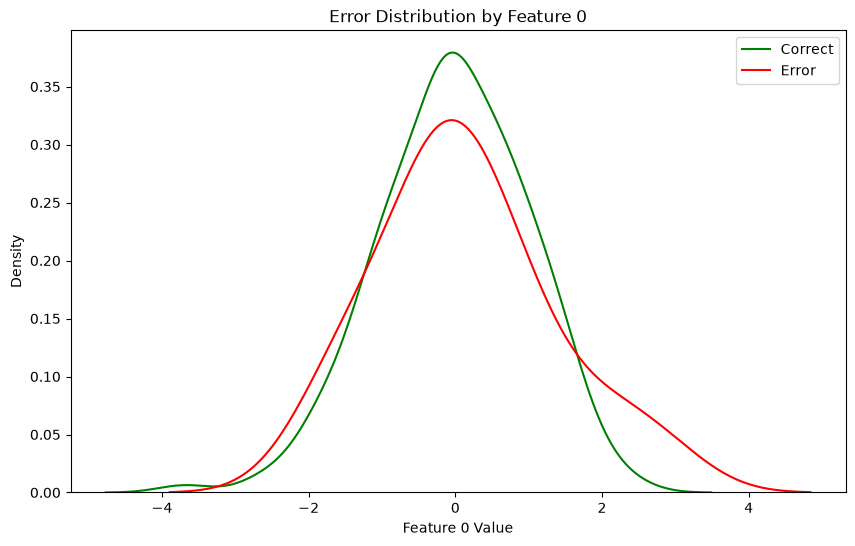

In [2]:
# Extract False Positives and False Negatives
fps = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]
fns = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

print(f"Number of False Positives: {len(fps)}")
print(f"Number of False Negatives: {len(fns)}")

# Error by Feature: Distribution of a feature for correct vs incorrect predictions
plt.figure(figsize=(10, 6))
sns.kdeplot(results_df[results_df['Error'] == False]['feat_0'], label='Correct', color='green')
sns.kdeplot(results_df[results_df['Error'] == True]['feat_0'], label='Error', color='red')
plt.title("Error Distribution by Feature 0")
plt.xlabel("Feature 0 Value")
plt.legend()
plt.show()

## Analyzing Regression Errors (Residuals)
In regression, we analyze the **Residual Plot**. A good model should have residuals randomly distributed around zero.

- **Patterns in Residuals:** If the residuals form a curve or a funnel (heteroscedasticity), it means the model is missing a non-linear relationship or the error variance changes with the target.
- **Error by Segment:** Checking if the model performs worse for high values vs low values of the target.

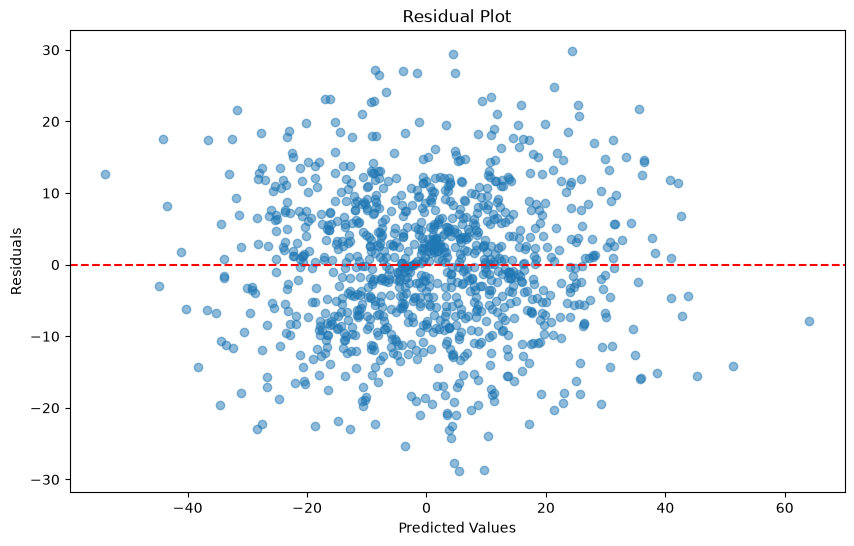

In [3]:
# Dummy regression error analysis
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

Xr, yr = make_regression(n_samples=1000, n_features=1, noise=10, random_state=42)
model_r = LinearRegression().fit(Xr, yr)
y_pred_r = model_r.predict(Xr)
residuals = yr - y_pred_r

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_r, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()